# Natural-Like Landmark Interpolation on a Grid

Given landmarks $(x_i, f_i)$, we interpolate values over a dense grid using normalized local influence weights:
$$
w_i(x)=\frac{V_i(x)}{\sum_j V_j(x)},\qquad
\hat f(x)=\sum_i w_i(x)f_i.
$$
We precompute distance-to-landmark fields and evaluate weights on all grid pixels.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython
ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

n = 140
x = np.linspace(-1,1,n); y = np.linspace(-1,1,n)
X, Y = np.meshgrid(x,y)

M = 14
pts = rng.uniform(-0.9,0.9,size=(M,2))
vals = np.sin(2.5*pts[:,0]) + 0.6*np.cos(3.0*pts[:,1])


In [2]:
# Precompute distance fields Vi(x)=1/(d(x,xi)^p + eps)
p = 2.2
eps = 1e-4
V = np.zeros((M, n, n))
for i in range(M):
    d2 = (X-pts[i,0])**2 + (Y-pts[i,1])**2
    V[i] = 1.0 / (d2**(p/2) + eps)
W = V / np.sum(V, axis=0, keepdims=True)
F = np.sum(W * vals[:,None,None], axis=0)


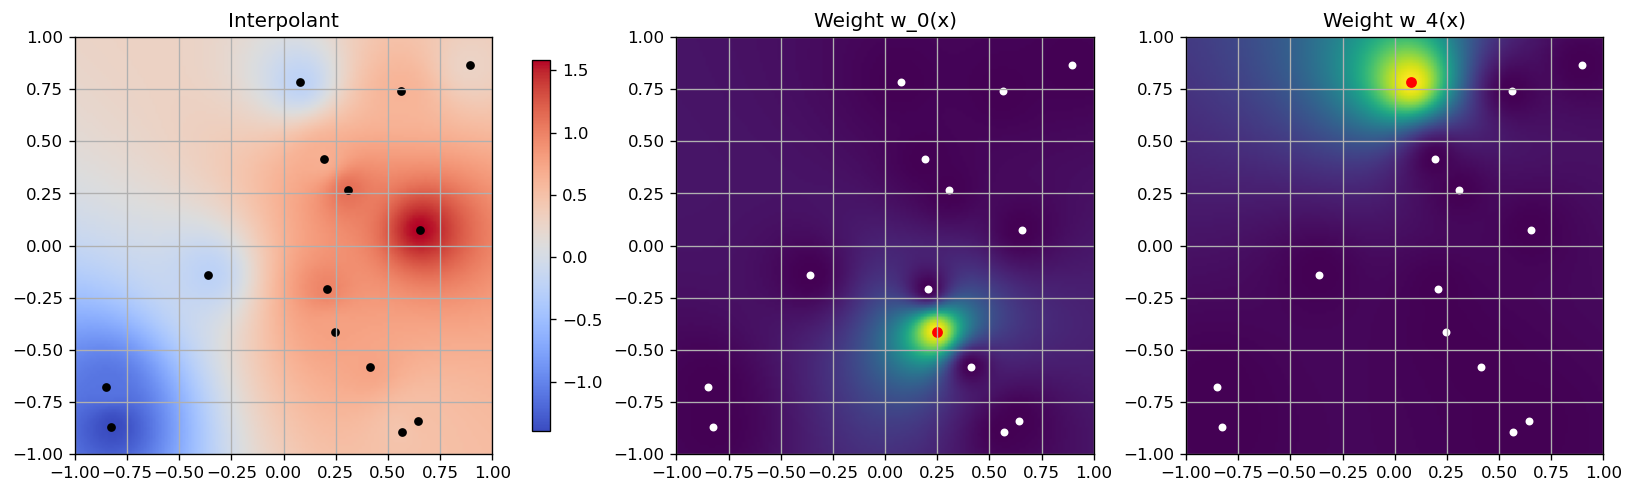

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), constrained_layout=True)
im = axes[0].imshow(F, origin='lower', extent=[-1,1,-1,1], cmap='coolwarm')
axes[0].scatter(pts[:,0], pts[:,1], c='k', s=18)
axes[0].set_title('Interpolant')
fig.colorbar(im, ax=axes[0], shrink=0.75)

show_i = [0, 4]
for ax, i in zip(axes[1:], show_i):
    imw = ax.imshow(W[i], origin='lower', extent=[-1,1,-1,1], cmap='viridis')
    ax.scatter(pts[:,0], pts[:,1], c='w', s=14)
    ax.scatter([pts[i,0]], [pts[i,1]], c='r', s=30)
    ax.set_title(f'Weight w_{i}(x)')
fig.savefig(OUT / "snippet.png", bbox_inches='tight')
plt.show()
